<a href="https://colab.research.google.com/github/LNzayo/Predicting-Housing-Prices-in-Buenos-Aires-with-Linear-Regression/blob/main/notebooks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Data Loading and Cleaning

In [14]:
# 01_data_loading_and_cleaning.ipynb

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load data
df = pd.read_csv('/content/buenos-aires-real-estate-1.csv')

# Extract neighborhood from 'place_with_parent_names'
def extract_neighborhood(s):
    if pd.isna(s) or not isinstance(s, str):
        return np.nan
    parts = [part.strip() for part in s.split('|') if part.strip()]
    if parts:
        return parts[-1]
    return np.nan

df['neighborhood'] = df['place_with_parent_names'].apply(extract_neighborhood)

# Drop columns that are not useful or are redundant after extraction
df = df.drop(columns=['place_with_parent_names', 'properati_url', 'currency'], errors='ignore')

# Handle 'lat-lon' column: split into latitude and longitude
df[['latitude', 'longitude']] = df['lat-lon'].str.split(',', expand=True)
df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')
df = df.drop(columns=['lat-lon'])

# --- Missing Value Handling --- #

# Impute missing categorical features with 'Unknown' BEFORE dropping any rows based on target
for col in ['neighborhood', 'property_type', 'operation']:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')

# Handle missing values for the target variable: drop rows where 'price_aprox_usd' is NaN
df_clean = df.dropna(subset=['price_aprox_usd'])

# Impute missing numerical features with their median (only on df_clean)
for col in ['surface_total_in_m2', 'surface_covered_in_m2', 'price_usd_per_m2', 'price_per_m2',
            'floor', 'rooms', 'expenses', 'latitude', 'longitude']:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Remove duplicates
df_clean = df_clean.drop_duplicates()

# Initial exploration (using df_clean for updated overview)
print("=== DATASET OVERVIEW ===")
print(f"Shape: {df_clean.shape}")
print(f"\nColumns: {df_clean.columns.tolist()}")
print(f"\nData types:")
print(df_clean.dtypes)

# Check missing values after cleaning
print("\n=== MISSING VALUES (after cleaning) ===")
print(df_clean.isnull().sum())

# Summary statistics (using df_clean)
print("\n=== SUMMARY STATISTICS (after cleaning) ===")
print(df_clean.describe())


# Ensure the data directory exists within the current working directory
os.makedirs('data', exist_ok=True)

# Save cleaned data to the 'data' directory
df_clean.to_csv('data/buenos-aires-properties-clean.csv', index=False)

print(f"\n Cleaned shape: {df_clean.shape}")

=== DATASET OVERVIEW ===
Shape: (8606, 17)

Columns: ['operation', 'property_type', 'place_with_parent_names', 'lat-lon', 'price', 'currency', 'price_aprox_local_currency', 'price_aprox_usd', 'surface_total_in_m2', 'surface_covered_in_m2', 'price_usd_per_m2', 'price_per_m2', 'floor', 'rooms', 'expenses', 'properati_url', 'neighborhood']

Data types:
operation                      object
property_type                  object
place_with_parent_names        object
lat-lon                        object
price                         float64
currency                       object
price_aprox_local_currency    float64
price_aprox_usd               float64
surface_total_in_m2           float64
surface_covered_in_m2         float64
price_usd_per_m2              float64
price_per_m2                  float64
floor                         float64
rooms                         float64
expenses                      float64
properati_url                  object
neighborhood                   object
dt

#2.Exploratory Data Analysis

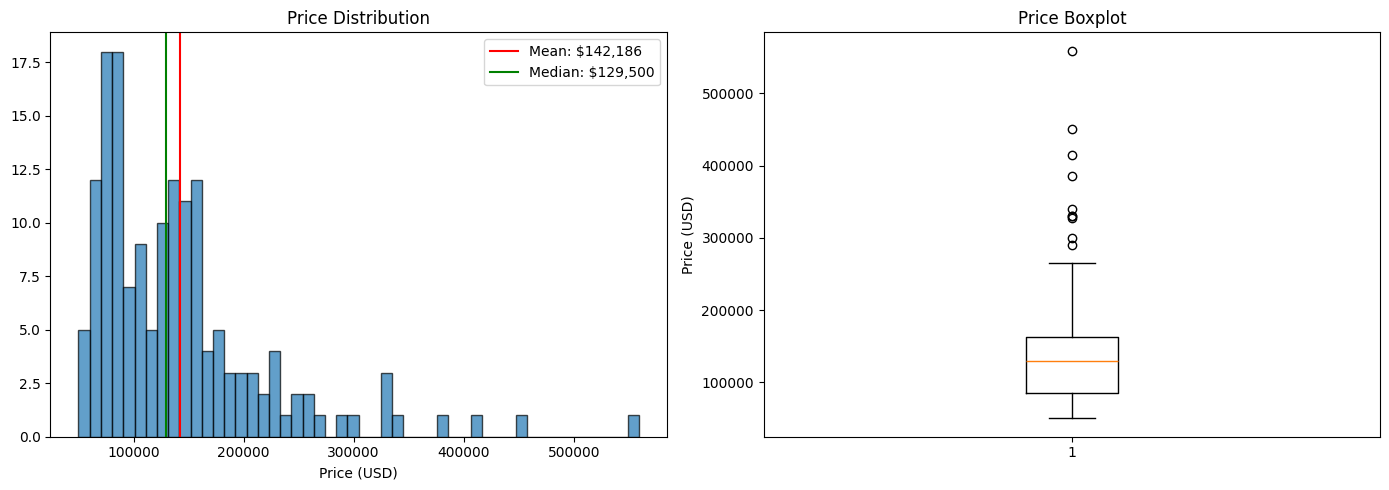

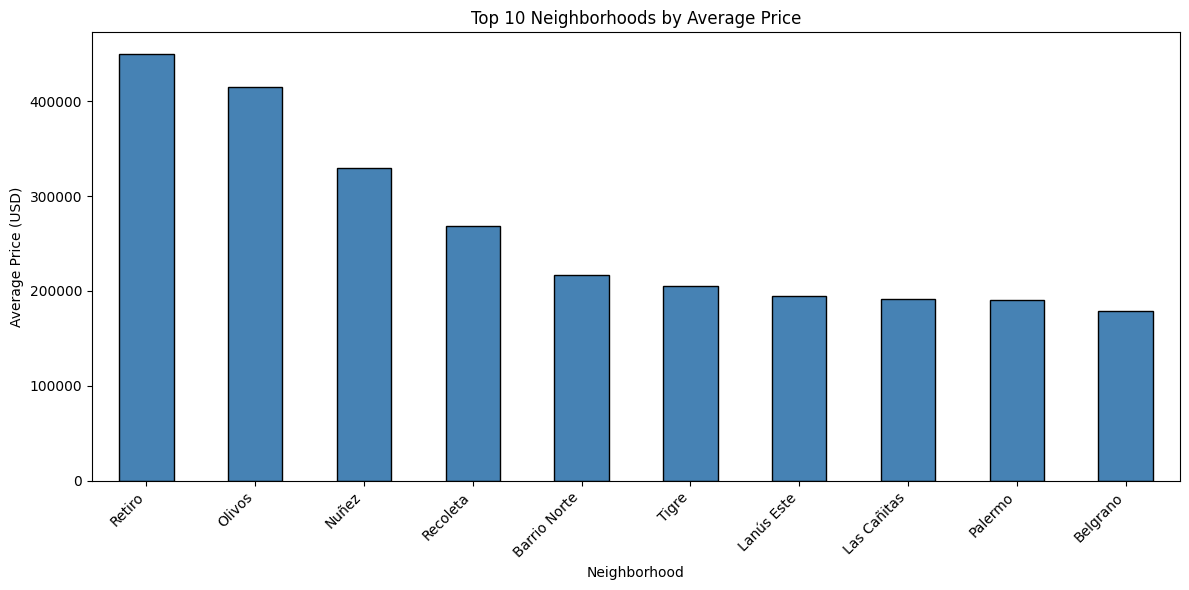

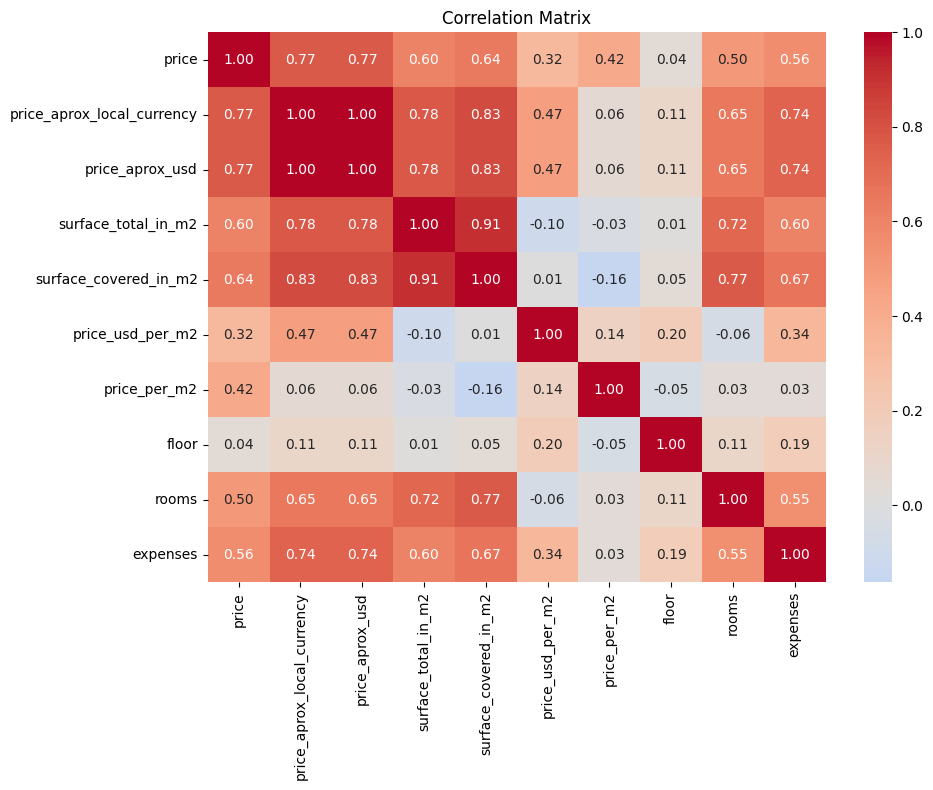


=== KEY INSIGHTS ===
1. Price range: $50,000 - $559,000
2. Mean price: $142,186
3. Median price: $129,500
4. Skew: Right-skewed
5. Most expensive neighborhood: Retiro ($450,000)
6. Cheapest neighborhood: Constitución ($57,000)


In [18]:
# 02_exploratory_data_analysis.ipynb

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os # Import os for directory creation

# Load cleaned data from the 'data' directory
df = pd.read_csv('data/buenos-aires-properties-clean.csv')

# 1. Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['price_aprox_usd'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(df['price_aprox_usd'].mean(), color='red',
                label=f'Mean: ${df["price_aprox_usd"].mean():,.0f}')
axes[0].axvline(df['price_aprox_usd'].median(), color='green',
                label=f'Median: ${df["price_aprox_usd"].median():,.0f}')
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price (USD)')
axes[0].legend()

# Boxplot
axes[1].boxplot(df['price_aprox_usd'])
axes[1].set_title('Price Boxplot')
axes[1].set_ylabel('Price (USD)')

plt.tight_layout()
# Ensure the results/figures directory exists
os.makedirs('results/figures', exist_ok=True)
plt.savefig('results/figures/price_distribution.png')
plt.show()

# 2. Price by Neighborhood
fig, ax = plt.subplots(figsize=(12, 6))
neighborhood_means = df.groupby('neighborhood')['price_aprox_usd'].mean().sort_values(ascending=False)
neighborhood_means.head(10).plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Top 10 Neighborhoods by Average Price')
ax.set_xlabel('Neighborhood')
ax.set_ylabel('Average Price (USD)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('results/figures/neighborhood_prices.png')
plt.show()

# 3. Correlation matrix
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.savefig('results/figures/correlation_matrix.png')
plt.show()

# 4. Key insights
print("\n=== KEY INSIGHTS ===")
print(f"1. Price range: ${df['price_aprox_usd'].min():,.0f} - ${df['price_aprox_usd'].max():,.0f}")
print(f"2. Mean price: ${df['price_aprox_usd'].mean():,.0f}")
print(f"3. Median price: ${df['price_aprox_usd'].median():,.0f}")
print(f"4. Skew: {'Right-skewed' if df['price_aprox_usd'].mean() > df['price_aprox_usd'].median() else 'Left-skewed'}")
print(f"5. Most expensive neighborhood: {neighborhood_means.index[0]} (${neighborhood_means.iloc[0]:,.0f})")
print(f"6. Cheapest neighborhood: {neighborhood_means.index[-1]} (${neighborhood_means.iloc[-1]:,.0f})")

#3.Feature Engineering

In [20]:
# 03_feature_engineering.ipynb

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load cleaned data
df = pd.read_csv('./data/buenos-aires-properties-clean.csv')

# 1. Create new features
df['price_per_m2'] = df['price_aprox_usd'] / df['surface_covered_in_m2']

# 2. One-hot encoding for categorical variables
df_encoded = pd.get_dummies(df, columns=['neighborhood', 'property_type', 'operation'], prefix=['neighborhood', 'property_type', 'operation'], dtype=int)

# Drop original 'price' and 'price_aprox_local_currency' as they are highly correlated/redundant with 'price_aprox_usd'
df_encoded = df_encoded.drop(columns=['price', 'price_aprox_local_currency'], errors='ignore')

# 3. Check the result
print(f"Original shape: {df.shape}")
print(f"Encoded shape: {df_encoded.shape}")
print(f"\nNew columns: {df_encoded.columns.tolist()}")

# 4. Save encoded data
os.makedirs('./data', exist_ok=True)
df_encoded.to_csv('./data/buenos-aires-properties-encoded.csv', index=False)

# 5. Feature selection
target = 'price_aprox_usd'
# Select only numerical features for correlation calculation and model training
features = [col for col in df_encoded.select_dtypes(include=np.number).columns if col != target]

print(f"\nFeatures: {len(features)}")
print(f"Target: {target}")

# 6. Check correlation with target
correlations = df_encoded[features + [target]].corr()[target].sort_values(ascending=False)
print("\n=== TOP FEATURES BY CORRELATION ===")
print(correlations.head(10))

Original shape: (159, 17)
Encoded shape: (159, 65)

New columns: ['place_with_parent_names', 'lat-lon', 'currency', 'price_aprox_usd', 'surface_total_in_m2', 'surface_covered_in_m2', 'price_usd_per_m2', 'price_per_m2', 'floor', 'rooms', 'expenses', 'properati_url', 'neighborhood_Abasto', 'neighborhood_Almagro', 'neighborhood_Avellaneda', 'neighborhood_Balvanera', 'neighborhood_Barrio Norte', 'neighborhood_Barrio Parque General San Martin', 'neighborhood_Belgrano', 'neighborhood_Boca', 'neighborhood_Boedo', 'neighborhood_Caballito', 'neighborhood_Caseros', 'neighborhood_Centro / Microcentro', 'neighborhood_Chacarita', 'neighborhood_Congreso', 'neighborhood_Constitución', 'neighborhood_Flores', 'neighborhood_Floresta', 'neighborhood_Haedo', 'neighborhood_Lanús Este', 'neighborhood_Las Cañitas', 'neighborhood_Liniers', 'neighborhood_Monserrat', 'neighborhood_Morón', 'neighborhood_Nuñez', 'neighborhood_Olivos', 'neighborhood_Once', 'neighborhood_Palermo', 'neighborhood_Parque Centenario', 

#4.Model Training

In [24]:
# 04_model_training.ipynb

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import os
import pickle

# Load encoded data
df = pd.read_csv('./data/buenos-aires-properties-encoded.csv')

# 1. Prepare features and target
target = 'price_aprox_usd'
# Explicitly select only numeric columns, excluding the target
numeric_cols = df.select_dtypes(include=np.number).columns
features = [col for col in numeric_cols if col != target]

X = df[features]
y = df[target]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# 3. Scale features (optional)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# 5. Make predictions
y_pred = model.predict(X_test_scaled)

# 6. Evaluate
print("\n=== MODEL PERFORMANCE ===")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred)):,.2f}")
print(f"MAE: ${mean_absolute_error(y_test, y_pred):,.2f}")

# 7. Feature importance (coefficients)
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

print("\n=== TOP 10 FEATURE COEFFICIENTS ===")
print(coef_df.head(10))

# 8. Save model and results
os.makedirs('./results', exist_ok=True)
with open('./results/model.pkl', 'wb') as f:
    pickle.dump(model, f)
with open('./results/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("\n Model and scaler saved!")

X shape: (159, 60)
y shape: (159,)

Training set: 127 samples
Test set: 32 samples

=== MODEL PERFORMANCE ===
R² Score: -6.2109
RMSE: $167,700.74
MAE: $49,005.08

=== TOP 10 FEATURE COEFFICIENTS ===
                      Feature   Coefficient
1       surface_covered_in_m2  50481.136606
0         surface_total_in_m2  26549.187111
2            price_usd_per_m2  25509.207159
3                price_per_m2  25083.524428
17       neighborhood_Caseros   5740.886650
42    neighborhood_San Miguel   5251.784084
5                       rooms   4278.898404
21  neighborhood_Constitución   3864.760041
9     neighborhood_Avellaneda   3784.178812
27       neighborhood_Liniers   2574.234442

✅ Model and scaler saved!


In [23]:
get_ipython().execute_cell("vY8ckFYDB3aL")

AttributeError: 'Shell' object has no attribute 'execute_cell'

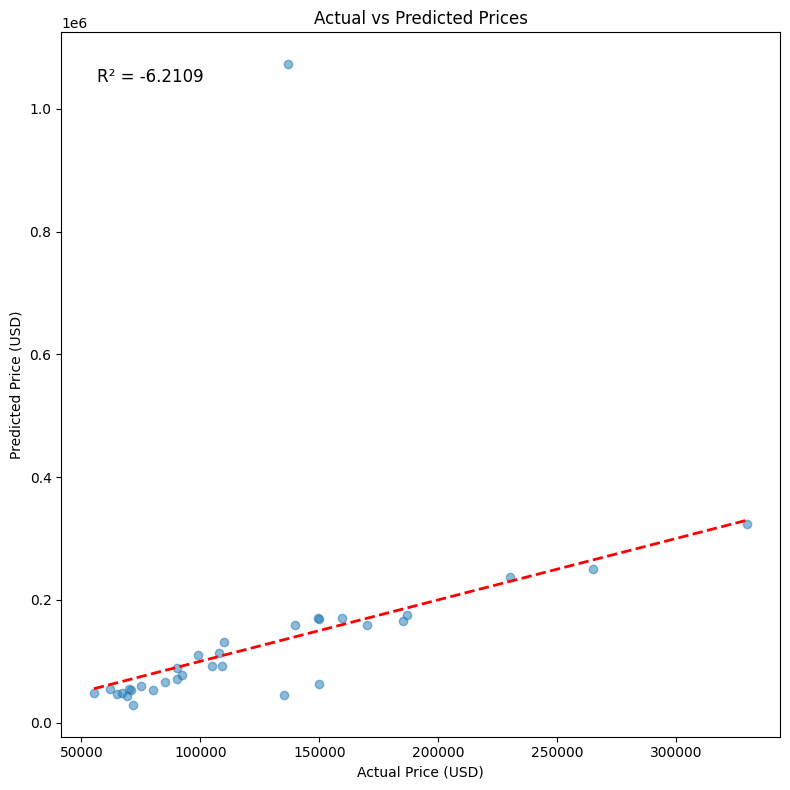

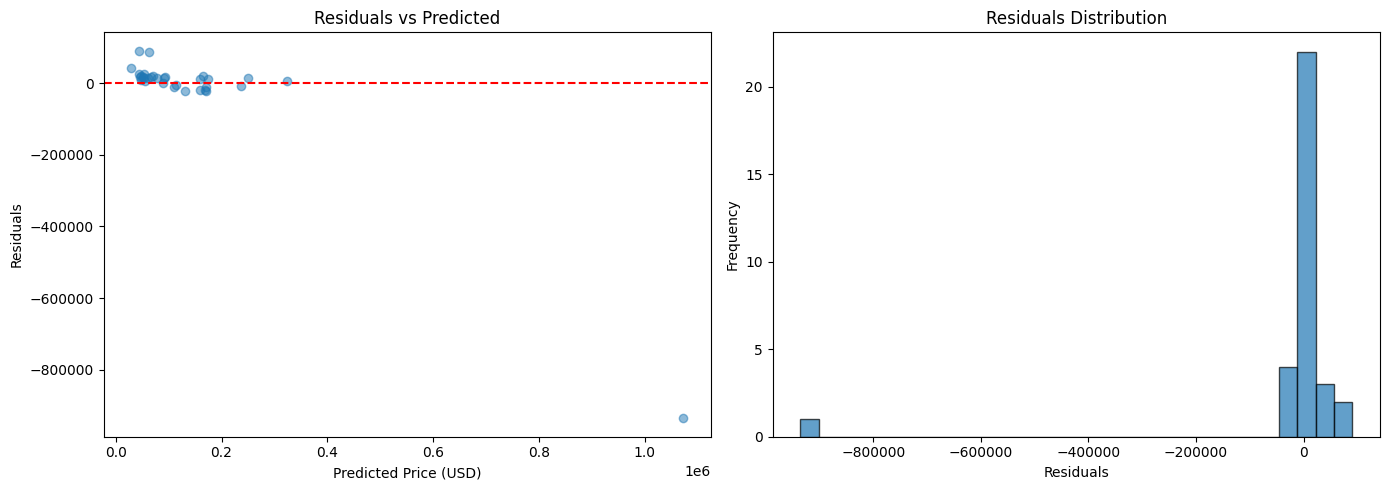

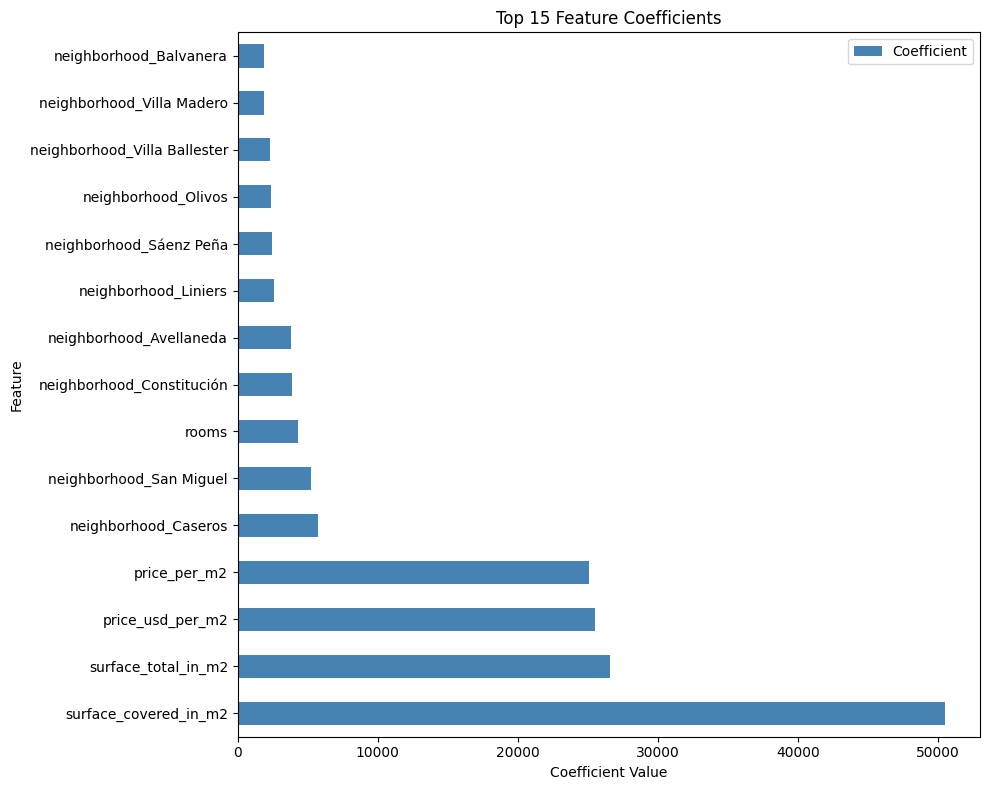

=== MODEL METRICS ===
R² Score: -6.2109
MSE: $28,123,539,758.66
RMSE: $167,700.74
MAE: $49,005.08
MAPE: 40.33%


In [28]:
# 05_model_evaluation.ipynb

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pickle
import os

# Ensure results/figures directory exists
os.makedirs('./results/figures', exist_ok=True)

# Load model and scaler
with open('./results/model.pkl', 'rb') as f:
    model = pickle.load(f)
with open('./results/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

# Load data
df = pd.read_csv('./data/buenos-aires-properties-encoded.csv')

# Prepare features and target
target = 'price_aprox_usd'
# Explicitly select only numeric columns, excluding the target
numeric_cols = df.select_dtypes(include=np.number).columns
features = [col for col in numeric_cols if col != target]

X = df[features]
y = df[target]

# Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale
X_test_scaled = scaler.transform(X_test)

# Predict
y_pred = model.predict(X_test_scaled)

# 1. Actual vs Predicted
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test, y_pred, alpha=0.5)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax.set_xlabel('Actual Price (USD)')
ax.set_ylabel('Predicted Price (USD)')
ax.set_title('Actual vs Predicted Prices')

# Add R² score
ax.text(0.05, 0.95, f'R² = {r2_score(y_test, y_pred):.4f}',
        transform=ax.transAxes, fontsize=12, verticalalignment='top')

plt.tight_layout()
plt.savefig('./results/figures/actual_vs_predicted.png')
plt.show()

# 2. Residuals
residuals = y_test - y_pred

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Predicted
ax1.scatter(y_pred, residuals, alpha=0.5)
ax1.axhline(y=0, color='red', linestyle='--')
ax1.set_xlabel('Predicted Price (USD)')
ax1.set_ylabel('Residuals')
ax1.set_title('Residuals vs Predicted')

# Residuals histogram
ax2.hist(residuals, bins=30, edgecolor='black', alpha=0.7)
ax2.set_xlabel('Residuals')
ax2.set_ylabel('Frequency')
ax2.set_title('Residuals Distribution')

plt.tight_layout()
plt.savefig('./results/figures/residual_plot.png')
plt.show()

# 3. Feature Importance
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
coef_df.head(15).plot(kind='barh', x='Feature', y='Coefficient', ax=ax, color='steelblue')
ax.set_title('Top 15 Feature Coefficients')
ax.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('./results/figures/feature_importance.png')
plt.show()

# 4. Model Metrics
print("=== MODEL METRICS ===")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"MSE: ${mean_squared_error(y_test, y_pred):,.2f}")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred)):,.2f}")
print(f"MAE: ${mean_absolute_error(y_test, y_pred):,.2f}")
print(f"MAPE: {np.mean(np.abs((y_test - y_pred) / y_test)) * 100:.2f}%")

# 5. Save metrics
os.makedirs('./results', exist_ok=True)
with open('./results/model_metrics.txt', 'w') as f:
    f.write("=== MODEL PERFORMANCE METRICS ===\n")
    f.write(f"R² Score: {r2_score(y_test, y_pred):.4f}\n")
    f.write(f"MSE: ${mean_squared_error(y_test, y_pred):,.2f}\n")
    f.write(f"RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred)):,.2f}\n")
    f.write(f"MAE: ${mean_absolute_error(y_test, y_pred):,.2f}\n")
    f.write(f"MAPE: {np.mean(np.abs((y_test - y_pred) / y_test)) * 100:.2f}%\n")

#5.Model Evaluation

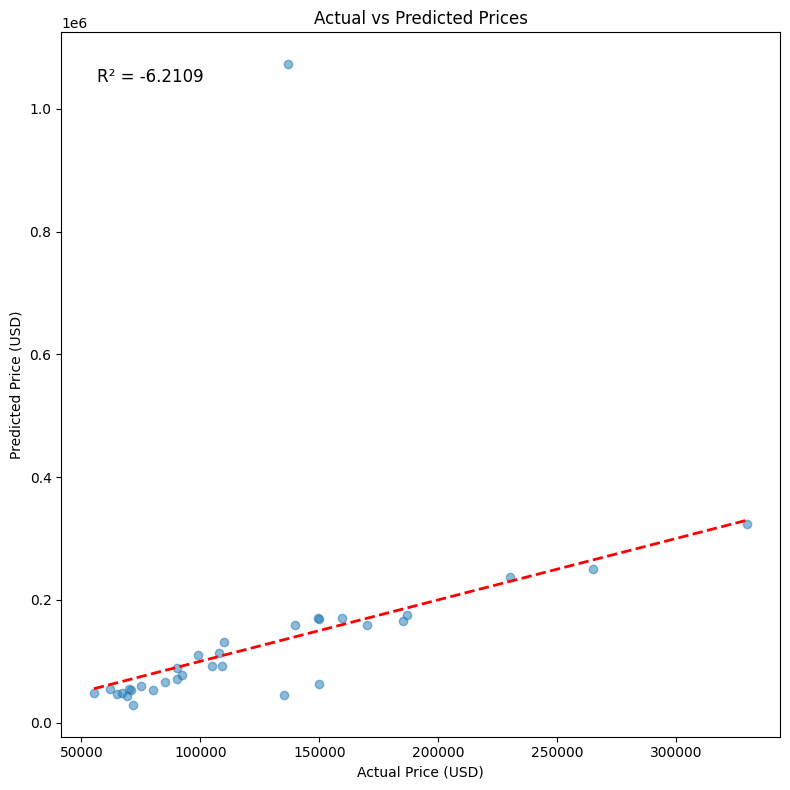

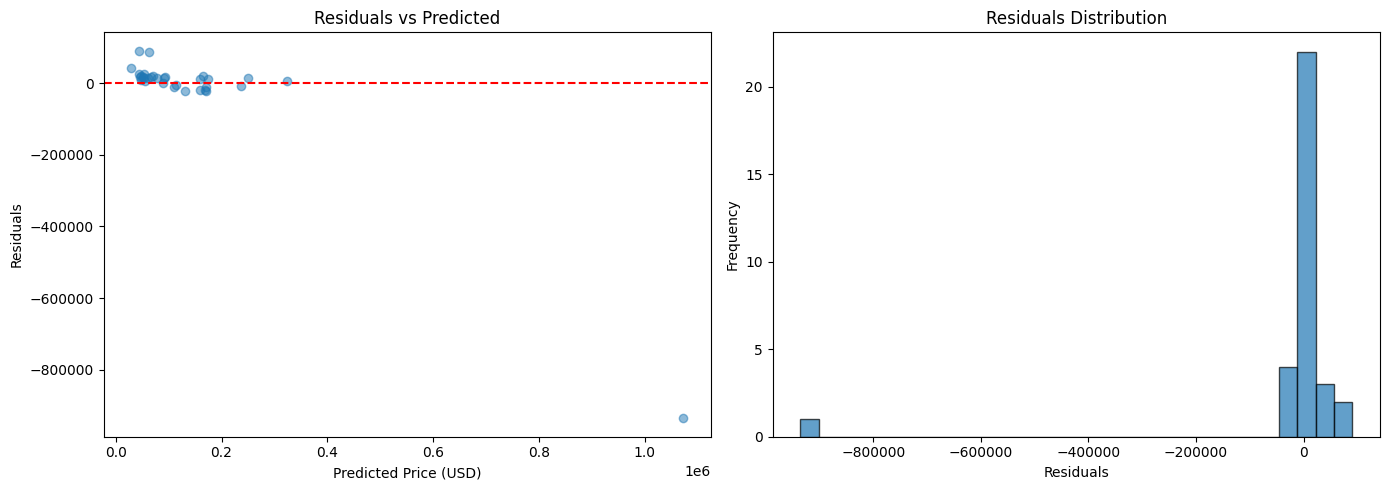

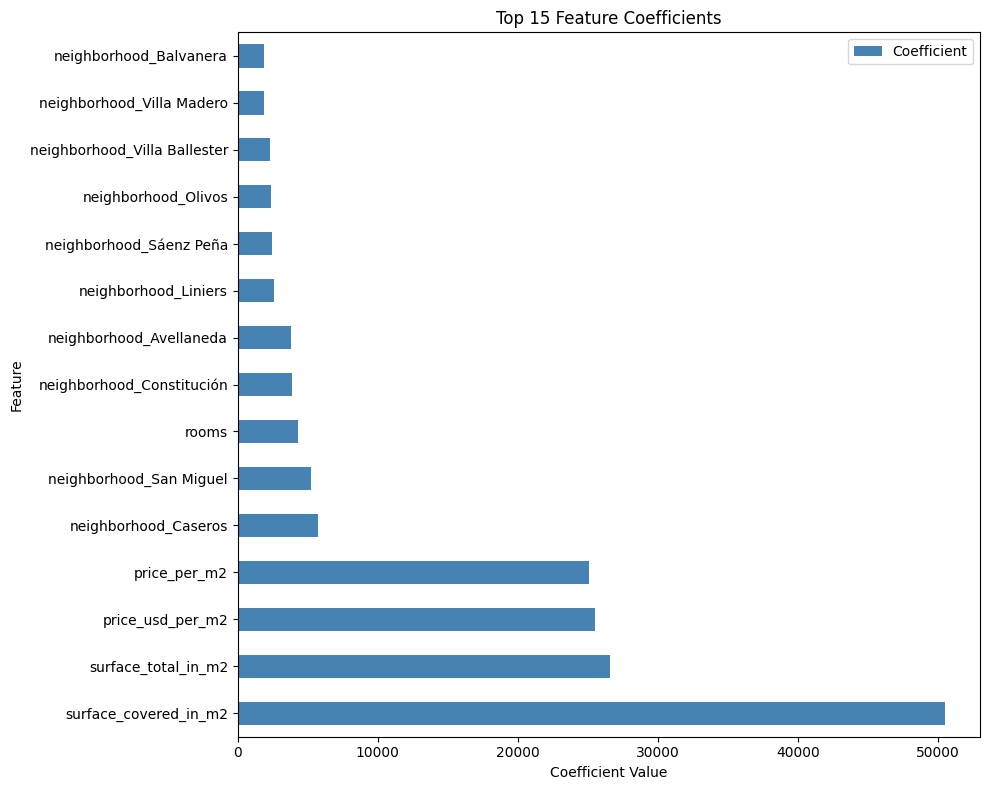

=== MODEL METRICS ===
R² Score: -6.2109
MSE: $28,123,539,758.66
RMSE: $167,700.74
MAE: $49,005.08
MAPE: 40.33%


In [32]:
# 05_model_evaluation.ipynb

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pickle
import os

# Ensure results/figures directory exists
os.makedirs('./results/figures', exist_ok=True)

# Load model and scaler
with open('./results/model.pkl', 'rb') as f:
    model = pickle.load(f)
with open('./results/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

# Load data
df = pd.read_csv('./data/buenos-aires-properties-encoded.csv')

# Prepare features and target
target = 'price_aprox_usd'
# Explicitly select only numeric columns, excluding the target
numeric_cols = df.select_dtypes(include=np.number).columns
features = [col for col in numeric_cols if col != target]

X = df[features]
y = df[target]

# Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale
X_test_scaled = scaler.transform(X_test)

# Predict
y_pred = model.predict(X_test_scaled)

# 1. Actual vs Predicted
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test, y_pred, alpha=0.5)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax.set_xlabel('Actual Price (USD)')
ax.set_ylabel('Predicted Price (USD)')
ax.set_title('Actual vs Predicted Prices')

# Add R² score
ax.text(0.05, 0.95, f'R² = {r2_score(y_test, y_pred):.4f}',
        transform=ax.transAxes, fontsize=12, verticalalignment='top')

plt.tight_layout()
plt.savefig('./results/figures/actual_vs_predicted.png')
plt.show()

# 2. Residuals
residuals = y_test - y_pred

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Predicted
ax1.scatter(y_pred, residuals, alpha=0.5)
ax1.axhline(y=0, color='red', linestyle='--')
ax1.set_xlabel('Predicted Price (USD)')
ax1.set_ylabel('Residuals')
ax1.set_title('Residuals vs Predicted')

# Residuals histogram
ax2.hist(residuals, bins=30, edgecolor='black', alpha=0.7)
ax2.set_xlabel('Residuals')
ax2.set_ylabel('Frequency')
ax2.set_title('Residuals Distribution')

plt.tight_layout()
plt.savefig('./results/figures/residual_plot.png')
plt.show()

# 3. Feature Importance
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
coef_df.head(15).plot(kind='barh', x='Feature', y='Coefficient', ax=ax, color='steelblue')
ax.set_title('Top 15 Feature Coefficients')
ax.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('./results/figures/feature_importance.png')
plt.show()

# 4. Model Metrics
print("=== MODEL METRICS ===")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"MSE: ${mean_squared_error(y_test, y_pred):,.2f}")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred)):,.2f}")
print(f"MAE: ${mean_absolute_error(y_test, y_pred):,.2f}")
print(f"MAPE: {np.mean(np.abs((y_test - y_pred) / y_test)) * 100:.2f}%")

# 5. Save metrics
os.makedirs('./results', exist_ok=True)
with open('./results/model_metrics.txt', 'w') as f:
    f.write("=== MODEL PERFORMANCE METRICS ===\n")
    f.write(f"R² Score: {r2_score(y_test, y_pred):.4f}\n")
    f.write(f"MSE: ${mean_squared_error(y_test, y_pred):,.2f}\n")
    f.write(f"RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred)):,.2f}\n")
    f.write(f"MAE: ${mean_absolute_error(y_test, y_pred):,.2f}\n")
    f.write(f"MAPE: {np.mean(np.abs((y_test - y_pred) / y_test)) * 100:.2f}%\n")